In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

In [2]:
# fig = plt.figure(figsize=(7.5, 3.5))
# gs_main = GridSpec(2, 1, hspace=0.4, height_ratios=[2, 2])
# gs_top = GridSpecFromSubplotSpec(2, 5, subplot_spec=gs_main[0], wspace=0.4, hspace=0.4)
# gs_bottom = GridSpecFromSubplotSpec(2, 5, subplot_spec=gs_main[1], wspace=0.4, hspace=0.4)


# amp_axes = [plt.subplot(gs_top[0:2, i]) for i in range(3)]
# cut_axes = [plt.subplot(gs_bottom[i//3, i%3]) for i in range(6)]
# label_spacer = 0.04

# analyzer = Lf_analysis(1840, contact=2)
# norm = colors.LogNorm(vmin=1e5, vmax=1e11)
# letters = list(map(chr, range(97, 97+5)))
# detrends = {
#     # 'No Background Subtraction': [lambda y, x: (x, 0), {}],
#     'Linear': [detrend_poly, {'degree': 1}],
#     'Savgol': [detrend_savgol, {'win':101, 'poly':3, 'max_win_frac':0.4}],
#     # 'Spline': [detrend_spline, {'n_knots': 10}],
#     'Butterworth': [detrend_butterworth, {'cutoff': None, 'order': 4}]
# }

# density_targets = [0.45, 0.9]
# density_colors = ['#E91E63', '#FF6B35']
# output_ffts = []

# for ax, letter, (name, (filter, filter_params)) in zip(amp_axes, letters, detrends.items()):
#     plot, linecuts_out = analyzer.plot_fft_invcm(fig, ax, norm,
#         bg_method=filter,                         
#         bg_method_params=filter_params, # Cutoff = None --> 4 periods
#         padding = 8, 
#         blims=(0.62, 4.98),
#         target_densities=density_targets
#     )
#     pos = ax.get_position()
#     output_ffts.append(linecuts_out)
#     for target_density, c  in zip(density_targets, density_colors):
#         density_idx = np.argmin(np.abs(target_density-analyzer.density))
#         ax.vlines(analyzer.density[density_idx], 0, 2, c, linestyle='dashed', alpha=0.8, lw=2)

#     fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letter, fontweight='bold')
#     ax.set_ylim(0, 1.5)
#     if name != 'No Background Subtraction':
#         ax.set_ylabel('')

#     if name == 'Butterworth':
#         cb_width = 0.3
#         cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
#         cb = plt.colorbar(plot, cax=cax, \
#                         orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.2)
#         cb.ax.set_ylabel(r'FFT amp. (a.u.)', labelpad=3)

    
# output_ffts = np.array(output_ffts)
# # LINECUTS
# for i, (name, (filter, filter_params)) in enumerate(detrends.items()):
#     for j, (target_density, c) in enumerate(zip(density_targets, density_colors)):
#         ax = cut_axes[3*j+i]
#         for spine in ax.spines.values():
#             spine.set_edgecolor(c)
#         psd, freq = output_ffts[i,j]

#         ax.plot(freq, psd, lw=1)
#         ax.set_yscale('log')
#         ax.set_ylim(1e5, 1e11)
#         ax.set_xlim(0, 1.5)
        
#         if j == 1:
#             ax.set_xlabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
#             if i == 0:
#                 ax.set_ylabel(r'FFT amp. (a.u.)', y=1.1)



# plt.savefig('figS_FFT_compare_bgsubmaps_v2.pdf', dpi=600, bbox_inches='tight',
#             pad_inches=0.02, transparent=False)






In [3]:
# Not using: save this here
# phasenorm = colors.Normalize(vmin=0, vmax=180)

# for ax, letter, (name, (filter, filter_params)) in zip(phase_axes, letters, detrends.items()):
#     plot = analyzer.plot_fft_invcm_phase(fig, ax, phasenorm,
#         bg_method=filter,                         
#         bg_method_params=filter_params, # Cutoff = None --> 4 periods
#         padding = 8, 
#         blims=(0.62, 4.98),
#     )
    
#     if name != 'No Background Subtraction':
#         ax.set_ylabel('')
    
    
#     pos = ax.get_position()
#     if name == 'Butterworth':
#         cb_width = 0.3
#         cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
#         cb = plt.colorbar(plot, cax=cax, ticks=[0,90,180], \
#                         orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.2)
#         cb.ax.set_ylabel(r'FFT phase (deg)', labelpad=3)
        

#     ax.set_ylim(0, 1.5)
# # plt.tight_layout()

### V3: Include BG subtracted LF

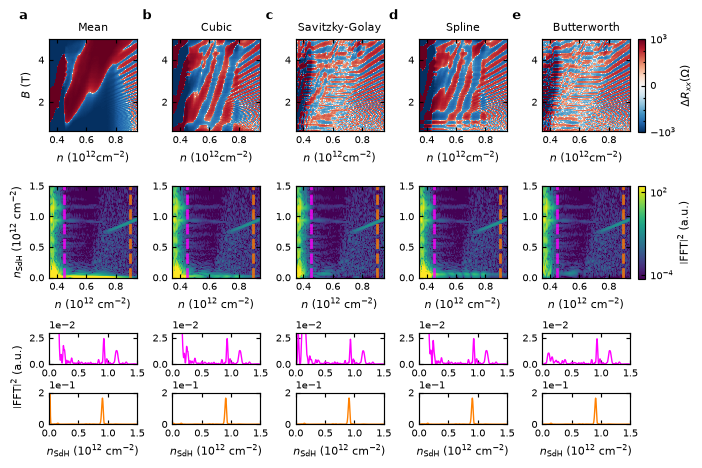

In [4]:
fig = plt.figure(figsize=(7.5, 5))

detrends = {
    'Mean': [lambda y, x: (x-np.mean(x), 0), {}],
    'Cubic': [detrend_poly, {'degree': 3}],
    'Savitzky-Golay': [detrend_savgol, {'win':101, 'poly':3, 'max_win_frac':0.4}],
    'Spline': [detrend_spline, {'n_knots': 10}],
    'Butterworth': [detrend_butterworth, {'cutoff': None, 'order': 4}]
}
n_pannels = len(detrends.keys())

gs_main = GridSpec(3, 1, hspace=0.6, height_ratios=[2, 2, 2])
gs_lf = GridSpecFromSubplotSpec(2, n_pannels, subplot_spec=gs_main[0], wspace=0.4, hspace=0.4)
gs_fft = GridSpecFromSubplotSpec(2, n_pannels, subplot_spec=gs_main[1], wspace=0.4, hspace=0.4)
gs_linecuts = GridSpecFromSubplotSpec(2, n_pannels, subplot_spec=gs_main[2], wspace=0.4, hspace=0.9)


lf_axes = [plt.subplot(gs_lf[0:2, i]) for i in range(n_pannels)]
amp_axes = [plt.subplot(gs_fft[0:2, i]) for i in range(n_pannels)]
cut_axes = [plt.subplot(gs_linecuts[i//n_pannels, i%n_pannels]) for i in range(2*n_pannels)]
label_spacer = 0.04

analyzer = Lf_analysis(1840, contact=2)
norm_lf = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)

letters = list(map(chr, range(97, 97+26)))

for ax, letter, (name, (filter, filter_params)) in zip(lf_axes, letters, detrends.items()):
    
    plot = analyzer.plot_lf(fig, ax, norm_lf,
        bg_method=filter,                         
        bg_method_params=filter_params, # Cutoff = None --> 4 periods
        blims=(0.62, 4.98),
        cmap='RdBu_r'
    )
    pos = ax.get_position()
    ax.set_title(name)
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letter, fontweight='bold')
    if name != 'Mean':
        ax.set_ylabel('')
    # ax.set_xlabel('')
    if name == 'Butterworth':
        cb_width = 0.3 *3.1/5
        cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
        cb = plt.colorbar(plot, cax=cax, ticks =[-1e3, 0, 1e3], \
                        orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.2)
        cb.ax.set_ylabel(r'$\Delta R_{xx} (\Omega)$', labelpad=3)




output_ffts = []

for ax, letter, (name, (filter, filter_params)) in zip(amp_axes, letters, detrends.items()):
    plot, linecuts_out = analyzer.plot_fft_invcm(fig, ax, norm_psd,
        bg_method=filter,                         
        bg_method_params=filter_params, # Cutoff = None --> 4 periods
        padding = 8, 
        blims=(0.62, 4.98),
        target_densities=density_targets
    )

    
    pos = ax.get_position()
    output_ffts.append(linecuts_out)
    for target_density, c  in zip(density_targets, density_colors):
        density_idx = np.argmin(np.abs(target_density-analyzer.density))
        ax.vlines(analyzer.density[density_idx], 0, 2, c, linestyle='dashed', alpha=0.8, lw=2)

    # fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letter, fontweight='bold')
    ax.set_ylim(0, 1.5)
    if name != 'Mean':
        ax.set_ylabel('')

    if name == 'Butterworth':
        cb_width = 0.3 *3.1 /5
        cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
        cb = plt.colorbar(plot, cax=cax,ticks=[1e-4, 1e2],\
                        orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.2)
        cb.ax.set_ylabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', labelpad=3)

    
output_ffts = np.array(output_ffts)
# LINECUTS
for i, (name, (filter, filter_params)) in enumerate(detrends.items()):
    for j, (target_density, c) in enumerate(zip(density_targets, density_colors)):
        ax = cut_axes[n_pannels*j+i]
        # for spine in ax.spines.values():
        #     spine.set_edgecolor(c)
        psd, freq = output_ffts[i,j]

        ax.plot(freq, psd, color=c, lw=1)
        ax.set_yscale('linear')
        if j == 0:
            ax.set_ylim(0, 3e-2)
        else: 
            ax.set_ylim(0, 2e-1)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax.set_xlim(0, 1.5)
        
        if j == 1:
            ax.set_xlabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
            if i == 0:
                ax.set_ylabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', y=1.5, labelpad=10.0)



plt.savefig('figS_FFT_compare_bgsubmaps_v4.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)




